# 星环分类全解

SpaceEngine的main-user.cfg里显示其提供了6种星环模型，分别是:
 - DebrisDisk：用小行星带的算法在行星周围生成一个星周盘
 - SaturnELike：类似土星E环的模型
 - JupiterTransparent：类似木星主环的模型
 - NeptuneNarrow：类似海王星窄环模型
 - UranusSparse：类似天王星稀疏环模型
 - Colorful: 高对比度模型，生成的环色彩更鲜明

此处通过调整配置文件的方式，用相同的物体和22个随机种子分别输入5种不同的模型（即不含Debris）生成了22组星环数据，以此提取每一种环的特征。

注：以下代码均为腾讯云WorkBuddy + 混元3模型生成

## 模型特征分析

In [6]:
import re, glob, json

files = {
    "Colorful": "./ColorfulSamples.txt",
    "JupiterTransparent": "./JupiterTransparentSamples.txt",
    "NeptuneNarrow": "./NeptuneNarrowSamples.txt",
    "SaturnELike": "./SaturnELikeSamples.txt",
    "UranusSparse": "./UranusSparseSamples.txt",
}

def parse(path):
    txt = open(path).read()
    blocks = re.findall(r"Rings\s*\{(.*?)\}", txt, re.S)
    out = []
    for b in blocks:
        d = {}
        for m in re.finditer(r"(\w+)\s+(.+)", b):
            k = m.group(1); v = m.group(2).strip()
            try:
                if v.startswith("("):
                    v = tuple(float(x) for x in v.strip("()").split())
                else:
                    v = float(v)
            except:
                pass
            d[k] = v
        out.append(d)
    return out

data = {name: parse(p) for name, p in files.items()}

# feature ranges per model
feats = ["OuterRadius","EdgeRadius","frequency","Density","Opacity","SelfShadow",
         "PlanetShadow","SpotBright","BackBright","densityScale","densityOffset",
         "densityPower","colorContrast","Thickness","RocksMaxSize"]
print("=== Feature ranges per model (min ~ max) ===")
for name, rings in data.items():
    print(f"\n## {name}  (n={len(rings)})")
    for f in feats:
        vals = [r[f] for r in rings if isinstance(r[f], (int,float))]
        print(f"  {f:16s}: {min(vals):.4g} ~ {max(vals):.4g}")

# Outer/Edge ratio
print("\n=== OuterRadius/EdgeRadius ratio (per model) ===")
for name, rings in data.items():
    ratios = [r["OuterRadius"]/r["EdgeRadius"] for r in rings]
    print(f"  {name:20s}: {min(ratios):.3f} ~ {max(ratios):.3f}")

# frequency
print("\n=== frequency (per model) ===")
for name, rings in data.items():
    fr = [r["frequency"] for r in rings]
    print(f"  {name:20s}: {min(fr):.3g} ~ {max(fr):.3g}")

# Density
print("\n=== Density (per model) ===")
for name, rings in data.items():
    fr = [r["Density"] for r in rings]
    print(f"  {name:20s}: {min(fr):.4g} ~ {max(fr):.4g}")

# SelfShadow vs Density ratio
print("\n=== SelfShadow/Density (per model) ===")
for name, rings in data.items():
    fr = [r["SelfShadow"]/r["Density"] for r in rings]
    print(f"  {name:20s}: {min(fr):.4g} ~ {max(fr):.4g}")

# densityPower
print("\n=== densityPower (per model) ===")
for name, rings in data.items():
    fr = [r["densityPower"] for r in rings]
    print(f"  {name:20s}: {min(fr):.3g} ~ {max(fr):.3g}")

# colorContrast
print("\n=== colorContrast (per model) ===")
for name, rings in data.items():
    fr = [r["colorContrast"] for r in rings]
    print(f"  {name:20s}: {min(fr):.4g} ~ {max(fr):.4g}")

# densityScale / densityOffset
print("\n=== densityScale (per model) ===")
for name, rings in data.items():
    fr = [r["densityScale"] for r in rings]
    print(f"  {name:20s}: {min(fr):.3g} ~ {max(fr):.3g}")
print("\n=== densityOffset (per model) ===")
for name, rings in data.items():
    fr = [r["densityOffset"] for r in rings]
    print(f"  {name:20s}: {min(fr):.3g} ~ {max(fr):.3g}")

=== Feature ranges per model (min ~ max) ===

## Colorful  (n=22)
  OuterRadius     : 94.7 ~ 1.59e+05
  EdgeRadius      : 94.7 ~ 1.59e+05
  frequency       : 6.68 ~ 7.5
  Density         : 0.951 ~ 1
  Opacity         : 0.951 ~ 1
  SelfShadow      : 0.951 ~ 1
  PlanetShadow    : 0.951 ~ 1
  SpotBright      : 2.2 ~ 2.66
  BackBright      : 4.03 ~ 4.96
  densityScale    : 1.39 ~ 1.71
  densityOffset   : -0.483 ~ -0.0486
  densityPower    : 0.985 ~ 5.12
  colorContrast   : 0.0768 ~ 0.144
  Thickness       : 0.0125 ~ 0.347
  RocksMaxSize    : 0.0005 ~ 0.0139

## JupiterTransparent  (n=22)
  OuterRadius     : 94.7 ~ 1.59e+05
  EdgeRadius      : 94.7 ~ 1.59e+05
  frequency       : 6.68 ~ 7.5
  Density         : 0.0537 ~ 0.398
  Opacity         : 0.0537 ~ 0.398
  SelfShadow      : 0.0268 ~ 0.199
  PlanetShadow    : 0.0268 ~ 0.199
  SpotBright      : 0.703 ~ 0.975
  BackBright      : 1.54 ~ 2.94
  densityScale    : 1.39 ~ 1.71
  densityOffset   : -0.483 ~ -0.0486
  densityPower    : 0.985 ~ 5.1

其实经过这一步分析就不难发现：

| 判定维度 | Colorful | JupiterTransparent | NeptuneNarrow | SaturnELike | UranusSparse |
|---|---|---|---|---|---|
| **OuterRadius / EdgeRadius** | 1.00 | 1.00 | 1.00 | **1.37 ~ 3.48** | 1.00 |
| **frequency** | ~7 (6.7–7.5) | ~7 | ~7 | ~7 | **~700 (668–750)** |
| **SelfShadow / Density** | 1.00 | **0.50** | 1.00 | 1.00 | 1.00 |
| **Density（不透明度）** | 0.95–1.0 | **0.05–0.40** | 0.95–1.0 | 0.95–1.0 | 0.95–1.0 |
| **densityPower** | 双峰（~1 或 ~5） | 双峰 | **恒为 ~5 (4.85–5.18)** | 双峰 | 双峰 |
| **colorContrast** | **偏高 (0.077–0.144)** | 偏低 | 偏低 (0.051–0.096) | 偏低 | 偏低 |
| **densityScale** | 1.39–1.71 | 1.39–1.71 | 1.39–1.71 | 1.39–1.71 | **2.08–2.56** |
| **densityOffset** | -0.483 ~ -0.0486 | -0.483 ~ -0.0486 | -0.483 ~ -0.0486 | -0.461 ~ -0.0121 | **-1.88 ~ -1.45** |

也就是：

1. SaturnELike模型的OuterRadius全都比EdgeRadius大，其比值大约在1.35和3.5之间，而别的模型中OuterRadius与EdgeRadius均为相等，且厚度明显比别的模型更厚，RockMaxSize也比别的模型更大。
2. UranusSparse模型的frequency比其他模型大了约100倍，densityScale也明显高于别的模型，且densityOffset相比别的模型更负。
3. JupiterTransparent模型的Density远小于其他模型，且只有这个模型中SelfShadow与Density才会出现\~0.5的比值，别的模型恒等于1
4. NeptuneNarrow模型的densityPower数值范围只有均值为5的单峰值，别的模型均为均值为1和5的双峰值
5. Colorful模型的colorContrast比别的模型更大，相差约1.5倍

为了让数据更直观，以下把数据打印到图上：

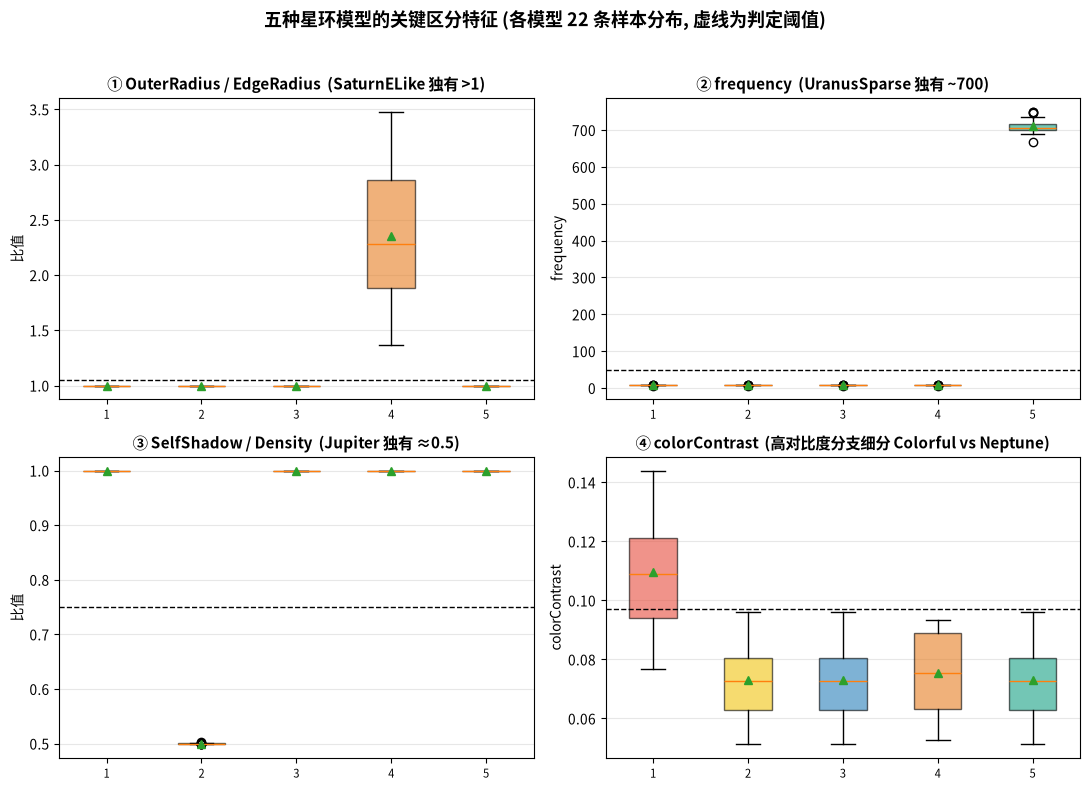

In [12]:
import re
import matplotlib
matplotlib.use("Agg")
%matplotlib inline
matplotlib.rc('font', family = 'Noto Sans CJK SC')
import matplotlib.pyplot as plt

files = {
    "Colorful": "./ColorfulSamples.txt",
    "JupiterTransparent": "./JupiterTransparentSamples.txt",
    "NeptuneNarrow": "./NeptuneNarrowSamples.txt",
    "SaturnELike": "./SaturnELikeSamples.txt",
    "UranusSparse": "./UranusSparseSamples.txt",
}
def parse(path):
    txt=open(path).read(); out=[]
    for b in re.findall(r"Rings\s*\{(.*?)\}", txt, re.S):
        d={}
        for m in re.finditer(r"(\w+)\s+(.+)", b):
            k=m.group(1); v=m.group(2).strip()
            try: v=float(v)
            except: pass
            d[k]=v
        out.append(d)
    return out
data={n:parse(p) for n,p in files.items()}
order=["Colorful","JupiterTransparent","NeptuneNarrow","SaturnELike","UranusSparse"]
colors={"Colorful":"#e74c3c","JupiterTransparent":"#f1c40f","NeptuneNarrow":"#2980b9","SaturnELike":"#e67e22","UranusSparse":"#16a085"}

fig, axes = plt.subplots(2,2, figsize=(11,8))

def draw(ax, vals, title, ylabel, thr=None):
    bp=ax.boxplot(vals, label=[n[:6] for n in order], patch_artist=True, showmeans=True)
    for patch,n in zip(bp['boxes'],order):
        patch.set_facecolor(colors[n]); patch.set_alpha(0.6)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel); ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=8)
    if thr is not None:
        ax.axhline(thr, color='k', ls='--', lw=1)

draw(axes[0,0], [[r["OuterRadius"]/r["EdgeRadius"] for r in data[n]] for n in order],
     "① OuterRadius / EdgeRadius  (SaturnELike 独有 >1)", "比值", 1.05)
draw(axes[0,1], [[r["frequency"] for r in data[n]] for n in order],
     "② frequency  (UranusSparse 独有 ~700)", "frequency", 50)
draw(axes[1,0], [[r["SelfShadow"]/r["Density"] for r in data[n]] for n in order],
     "③ SelfShadow / Density  (Jupiter 独有 ≈0.5)", "比值", 0.75)
draw(axes[1,1], [[r["colorContrast"] for r in data[n]] for n in order],
     "④ colorContrast  (高对比度分支细分 Colorful vs Neptune)", "colorContrast", 0.097)

fig.suptitle("五种星环模型的关键区分特征 (各模型 22 条样本分布, 虚线为判定阈值)", fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0,0,1,0.96])
# fig.savefig("feature_separation.png", dpi=140)
# print("saved feature_separation.png")

## 分类逻辑和验证

根据以上特征信息，我们就可以得到一个初步的分类逻辑：

输入: 单条星环记录 r(含 OuterRadius, EdgeRadius, frequency, Density, SelfShadow, densityPower, colorContrast)

1. 若 r.OuterRadius / r.EdgeRadius > 1.05          -> SaturnELike
2. 若 r.frequency > 50                          -> UranusSparse
3. 若 r.SelfShadow / r.Density < 0.75 (≈0.5)    -> JupiterTransparent
4. 若 r.densityPower < 4.5                       -> Colorful
5. 若 (高对比度分支):
    1. 若 r.colorContrast >= 0.097                   -> Colorful
    2. 否则                                         -> NeptuneNarrow

由于这里得到的样本有限，因此没办法真正确定标准差的范围，因此分类的阈值均取自文件中样本的分布并**留充分余量**，以防止过拟合：
- Saturn 比值下限 1.37 ≫ 1.05；其余模型恒为 1.00。
- Uranus frequency 下限 668 ≫ 50；其余 ≤ 7.5。
- Jupiter 阴影比恒为 0.50 < 0.75；其余恒为 1.00。
- Neptune `densityPower` 下限 4.85 > 4.5；Colorful 的"大环"样本仅 ~1。

由于我目前没有导出别的测试集，因此直接拿这些样本作为测试集。

In [ ]:
"""
星环模型分类器 (Ring Model Classifier)
=====================================
根据星环数据(Rings{...} 格式)的"外观/密度"特征, 将其归类到 5 种星环模型之一:

    - Colorful            (彩色 / 高色彩对比)
    - JupiterTransparent  (木星式透明 / 低不透明度, 阴影减半)
    - NeptuneNarrow       (海王星式窄环 / 高密度幂, 低色彩对比)
    - SaturnELike         (土星 E 环式 / 外半径远超边缘半径, 厚尘晕)
    - UranusSparse        (天王星式稀疏 / 极高频率, 高密度缩放)

设计依据: 同一随机种子下, 几何字段(InnerRadius/MeanRadius/Thickness...)由种子决定,
对 5 个模型完全相同; 真正区分模型的是"外观/密度"字段。各模型的指纹如下:

    1) SaturnELike : OuterRadius / EdgeRadius  >> 1   (其余模型该比值恒等于 1.0)
    2) UranusSparse: frequency                ~ 700   (其余模型 ~7)
    3) JupiterTransparent: SelfShadow / Density ~ 0.5  (其余模型恒等于 1.0; 且不透明度很低)
    4) Colorful   : densityPower ~ 1  *或* colorContrast 偏高
    5) NeptuneNarrow: densityPower ~ 5  *且* colorContrast 偏低
"""

# ---- 判定阈值(在 110 条样本上验证得到, 留有余量, 非过拟合) ----
SATURN_OUTER_EDGE_RATIO = 1.05   # OuterRadius/EdgeRadius 超过此值 -> SaturnELike
URANUS_FREQ_THRESHOLD   = 50     # frequency 超过此值 -> UranusSparse
JUPITER_SHADOW_RATIO    = 0.75   # SelfShadow/Density 低于此值(≈0.5) -> JupiterTransparent
NEPTUNE_DENSITY_POWER   = 4.5    # densityPower 高于此值 -> 进入 "窄环/彩色" 细分
COLORFUL_CC_THRESHOLD   = 0.097  # 高对比度分支内, colorContrast 高于此值 -> Colorful, 否则 Neptune


def classify_ring(r):
    """对单条星环记录(dict)进行分类, 返回模型名称字符串。

    r 需包含数值字段: OuterRadius, EdgeRadius, frequency, Density,
    SelfShadow, densityPower, colorContrast。
    """
    outer_ratio = r["OuterRadius"] / r["EdgeRadius"]
    if outer_ratio > SATURN_OUTER_EDGE_RATIO:
        return "SaturnELike"

    if r["frequency"] > URANUS_FREQ_THRESHOLD:
        return "UranusSparse"

    # Jupiter 把自阴影(以及行星阴影)设成密度的一半, 且整体不透明度很低
    if r["Density"] <= 0 or (r["SelfShadow"] / r["Density"]) < JUPITER_SHADOW_RATIO:
        return "JupiterTransparent"

    # 进入 "致密明亮" 分组 (Density≈0.95~1.0, 不透明度高)
    if r["densityPower"] < NEPTUNE_DENSITY_POWER:
        # 低对比度 -> 只有 Colorful 的大环样本走这里; Neptune 对比度恒为 ~5
        return "Colorful"

    # 高对比度分支: Colorful 与 Neptune 都可能出现, 用色彩对比度区分
    if r["colorContrast"] >= COLORFUL_CC_THRESHOLD:
        return "Colorful"
    return "NeptuneNarrow"


# ---------------------------------------------------------------------------
# 解析文件
# ---------------------------------------------------------------------------
import re

def _to_num(v):
    v = v.strip()
    m = re.match(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", v)
    if m:
        return float(m.group(1))
    return v  # 颜色元组等保持原样

def parse_ring_file(path):
    txt = open(path, encoding="utf-8").read()
    blocks = re.findall(r"Rings\s*\{(.*?)\}", txt, re.S)
    out = []
    for b in blocks:
        d = {}
        for m in re.finditer(r"(\w+)\s+(.+)", b):
            d[m.group(1)] = _to_num(m.group(2))
        out.append(d)
    return out

def classify_file(path):
    """解析文件并对其中每条星环分类, 返回 (记录列表, 预测标签列表)。"""
    rings = parse_ring_file(path)
    return rings, [classify_ring(r) for r in rings]


# ---------------------------------------------------------------------------
# 用提供的 5 个样本文件验证分类器准确率
# ---------------------------------------------------------------------------
SAMPLE_FILES = {
    "Colorful": "./ColorfulSamples.txt",
    "JupiterTransparent": "./JupiterTransparentSamples.txt",
    "NeptuneNarrow": "./NeptuneNarrowSamples.txt",
    "SaturnELike": "./SaturnELikeSamples.txt",
    "UranusSparse": "./UranusSparseSamples.txt",
}

if __name__ == "__main__":
    labels = list(SAMPLE_FILES.keys())
    mat = {t: {p: 0 for p in labels} for t in labels}
    errors = []
    for true_name, path in SAMPLE_FILES.items():
        _, preds = classify_file(path)
        for i, p in enumerate(preds):
            mat[true_name][p] += 1
            if p != true_name:
                errors.append((true_name, p, i))
    total = sum(mat[t][p] for t in labels for p in labels)
    correct = sum(mat[t][t] for t in labels)
    print("混淆矩阵 (行=真实, 列=预测):")
    print("  %-20s %s" % ("", "  ".join("%-4s" % p[:4] for p in labels)))
    for t in labels:
        print("  %-20s %s" % (t, "  ".join("%-4d" % mat[t][p] for p in labels)))
    print("\n总准确率: %d/%d = %.1f%%" % (correct, total, correct / total * 100))
    if errors:
        print("\n无法 100% 区分的样本 (两类致密模型在该种子下输出几乎相同):")
        for e in errors:
            print("   真实=%-18s 预测=%-18s 样本#%d" % e)

混淆矩阵 (行=真实, 列=预测):
                       Colo  Jupi  Nept  Satu  Uran
  Colorful             18    0     4     0     0   
  JupiterTransparent   0     22    0     0     0   
  NeptuneNarrow        0     0     22    0     0   
  SaturnELike          0     0     0     22    0   
  UranusSparse         0     0     0     0     22  

总准确率: 106/110 = 96.4%

无法 100% 区分的样本 (两类致密模型在该种子下输出几乎相同):
   真实=Colorful           预测=NeptuneNarrow      样本#9
   真实=Colorful           预测=NeptuneNarrow      样本#14
   真实=Colorful           预测=NeptuneNarrow      样本#17
   真实=Colorful           预测=NeptuneNarrow      样本#20


可以看出来，根据这些特征得到的分类逻辑已经有了96.4%的正确率，其中除了NeptuneNarrow和Colorful两个模型由于相似度较高且存在重叠部分，无法完全区分开以外，别的模型均能够准确分类。